# Laboratorio 15. Redes recurrentes

**Pregunta guía:** ¿Cómo resume una red recurrente una secuencia paso a paso?

## Objetivos
Al finalizar podrás desenrollar una celda recurrente simple con NumPy; visualizar estado oculto; reconocer dependencia del orden.

## Prerrequisitos y conexión
Las capas convolucionales (12–14) explotan vecindad espacial; ahora el orden temporal es central. Se requiere Python básico; cada notebook puede ejecutarse de forma independiente desde un kernel limpio.

## Teoría breve
Una celda recurrente actualiza $h_t=\tanh(W_xx_t+W_hh_{t-1}+b)$. Los pesos se comparten en cada paso, pero las secuencias largas pueden dificultar el flujo de gradiente.

## Problema y datos
Procesamos una secuencia sintética con una celda y comparamos el estado por paso. Todos los datos se generan en el notebook: no se requieren descargas ni archivos locales.

## Experimento conceptual
¿Cómo cambia el estado oculto a medida que recibe nuevos elementos? Fija la semilla, ejecuta las celdas en orden y cambia una decisión cada vez.


### Preparación del entorno
Importamos NumPy y PyTorch, fijamos semillas y elegimos CPU o GPU de forma opcional.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F

SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.figsize'] = (7, 4)
print('PyTorch:', torch.__version__, '| dispositivo:', device)


PyTorch: 2.8.0+cpu | dispositivo: cpu


**Resultado e interpretación.** La celda confirma el entorno utilizado. El resto del laboratorio está diseñado para CPU; una GPU disponible se utiliza sin ser requisito.


### Desenrollar la celda en NumPy
Aplicamos la misma matriz recurrente a cada paso y registramos los estados.


secuencia: (30,) | estados: (30, 3)


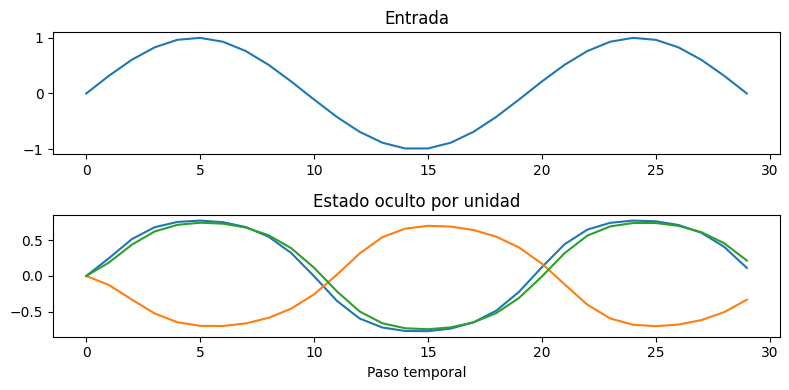

In [2]:
sequence = np.sin(np.linspace(0, 3*np.pi, 30)).astype(np.float32)
Wx = np.array([[0.8], [-0.4], [0.6]], dtype=np.float32)
Wh = np.array([[0.4, 0.1, 0.0], [0.0, 0.5, -0.2], [0.2, 0.0, 0.3]], dtype=np.float32)
hidden = np.zeros(3, dtype=np.float32); states = []
for value in sequence:
    hidden = np.tanh(Wx[:, 0] * value + Wh @ hidden)
    states.append(hidden.copy())
states = np.array(states)
print('secuencia:', sequence.shape, '| estados:', states.shape)
fig, axes = plt.subplots(2, 1, figsize=(8, 4)); axes[0].plot(sequence); axes[0].set_title('Entrada')
axes[1].plot(states); axes[1].set_title('Estado oculto por unidad'); axes[1].set_xlabel('Paso temporal'); plt.tight_layout(); plt.show()


**Resultado e interpretación.** Cada nuevo estado resume la entrada actual y un resumen anterior. La celda simple no preserva necesariamente información lejana.


## Limitaciones y conclusiones clave
Los resultados dependen de esta semilla, tamaño de muestra, arquitectura y protocolo. No extrapoles métricas sintéticas a datos reales; separa decisiones de modelado de conclusiones generales. La celda de salida aporta la evidencia numérica y visual para responder la pregunta guía.

- Los parámetros y activaciones determinan cómo se representa la señal.
- La pérdida, el optimizador y el protocolo de evaluación forman parte del experimento.
- Una métrica aislada no describe todos los errores ni garantiza generalización.

## Ejercicios progresivos
1. **Guiado:** Guiado: cambia el estado inicial y observa cuándo se atenúa su efecto.
2. **Independiente:** Independiente: cambia `Wh` y compara estabilidad y saturación de los estados.
3. **Desafío:** Desafío: agrega una salida por paso y especifica cómo entrenarías una predicción de secuencia.

## Conexión con el siguiente laboratorio
Usa la representación, operación o criterio de evaluación de este laboratorio como punto de partida del siguiente paso de la secuencia.
